# German Credit Risk — Credit Classification

## Цель проекта

Цель проекта — построить модель бинарной классификации,
которая предсказывает кредитный риск клиента.

Мы хотим определить, относится ли заявка клиента к:

- `good` — низкий кредитный риск;
- `bad` — высокий кредитный риск.

В рамках проекта мы:

1. исследуем исходные данные;
2. обрабатываем пропуски и категориальные признаки;
3. создаём новые признаки;
4. строим baseline-модель;
5. сравниваем несколько алгоритмов машинного обучения;
6. проводим cross-validation;
7. настраиваем гиперпараметры лучшей модели;
8. подбираем оптимальный threshold;
9. оцениваем итоговую модель на независимом test set.

## 1. Импорт библиотек

На первом этапе подключаем библиотеки для:

- работы с данными — `pandas`, `numpy`;
- визуализации — `matplotlib`, `seaborn`;
- построения и оценки ML-моделей — `scikit-learn`;
- использования бустингов — `LightGBM`, `XGBoost`, `CatBoost`.

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Загрузка данных

Загрузим исходный датасет German Credit Risk.

Перед построением модели необходимо понять:

- сколько объектов содержится в выборке;
- какие признаки доступны;
- какие признаки числовые;
- какие признаки категориальные;
- присутствуют ли пропущенные значения;
- как распределён target.

In [334]:
df = pd.read_csv("../data/raw/german_credit_data.csv", sep=",")

In [335]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Первичный просмотр данных

Первые строки позволяют проверить структуру таблицы,
названия признаков и корректность загрузки данных.

## 3. Очистка данных

В датасете присутствует `Unnamed: 0`.

Это технический индекс, который не содержит информации
о кредитном риске клиента, поэтому его необходимо удалить.

Оставлять такой признак в модели не имеет смысла:
он не описывает объект и потенциально может создавать шум.

In [336]:
df = df.drop(columns="Unnamed: 0")

## 4. Определение целевой переменной

Целевая переменная — `Risk`.

Она содержит два класса:

- `good`;
- `bad`.

Для обучения моделей классификации преобразуем их
в бинарное представление.

В проекте:

- `0` — `good`;
- `1` — `bad`.

Такое кодирование позволит использовать стандартные
метрики бинарной классификации.

In [337]:
df['Risk'].unique()

<StringArray>
['good', 'bad']
Length: 2, dtype: str

In [338]:
df['Risk'] = df['Risk'].map({
    'good': 0,
    'bad': 1
})

## 5. Первичный анализ данных

Изучим:

- типы признаков;
- количество наблюдений;
- наличие пропусков;
- базовые статистики числовых признаков.

In [339]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   int64
dtypes: int64(5), str(5)
memory usage: 78.3 KB


### Типы данных

В датасете представлены как числовые, так и категориальные признаки.

Отдельного внимания требуют категориальные признаки,
поскольку перед подачей в большинство ML-моделей
их необходимо преобразовать в числовое представление.

## 6. Пропущенные значения

Проверим количество пропусков в каждом признаке.

Пропуски присутствуют в:

- `Checking account`;
- `Saving accounts`.

Вместо удаления строк будем рассматривать отсутствие
информации как отдельную категорию.

Это позволяет сохранить все 1000 наблюдений
и одновременно не потерять информацию о том,
что у клиента отсутствует соответствующий счёт.

In [340]:
df.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

### Обработка пропусков

Заменяем `NaN` на категорию `No account`.

Таким образом, модель сможет отдельно учитывать клиентов,
для которых информация о счёте отсутствует.

In [341]:
df["Checking account"] = (
    df["Checking account"]
    .fillna("No account")
)

In [342]:
df["Saving accounts"] = (
    df["Saving accounts"]
    .fillna("No account")
)

## 7. Описательная статистика

Рассмотрим распределения основных числовых признаков.

Особое внимание обращаем на:

- `Credit amount`;
- `Duration`;
- `Age`.

Для `Credit amount` наблюдается большой разброс значений:
сумма кредита существенно отличается между клиентами,
что также отражается в высоком стандартном отклонении.

Это может быть полезно учитывать при feature engineering.

In [343]:
df.describe()

,Age,Job,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000,0.300000
std,11.375469,0.653614,2822.736876,12.058814,0.458487
min,19.000000,0.000000,250.000000,4.000000,0.000000
25%,27.000000,2.000000,1365.500000,12.000000,0.000000
50%,33.000000,2.000000,2319.500000,18.000000,0.000000
75%,42.000000,2.000000,3972.250000,24.000000,1.000000
max,75.000000,3.000000,18424.000000,72.000000,1.000000


## 8. Анализ распределений

Построим распределения числовых признаков.

Нас интересует:

- форма распределения;
- наличие асимметрии;
- выбросы;
- диапазон значений.

Особое внимание уделим `Credit amount` и `Duration`,
поскольку их распределение может существенно влиять
на обучение моделей.

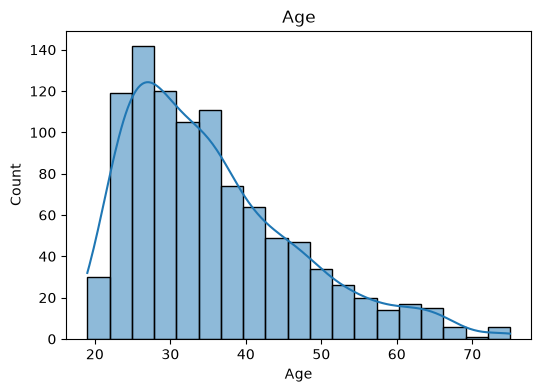

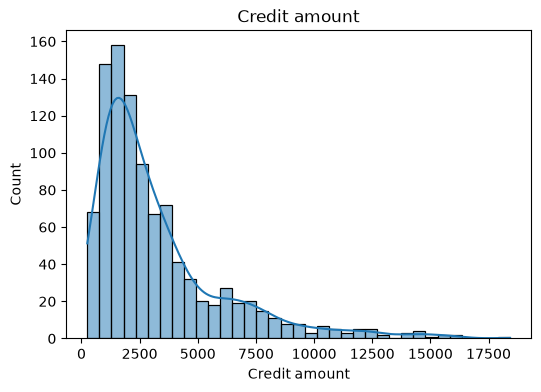

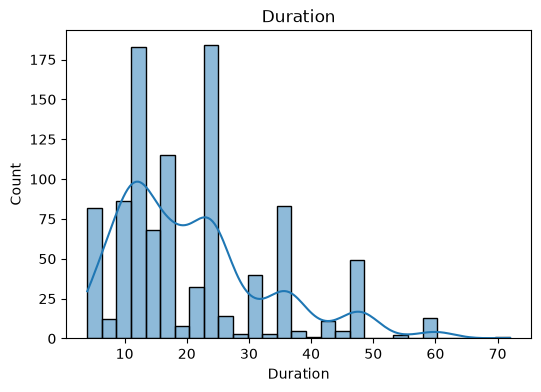

In [344]:
num_cols = ["Age", "Credit amount", "Duration"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### Наблюдения

`Credit amount` имеет выраженный разброс и длинный правый хвост.

`Duration` также имеет асимметрию.

Для некоторых моделей это может быть аргументом
в пользу логарифмического преобразования признаков.

## 9. Анализ категориальных признаков

Проверим количество уникальных значений каждого признака.

Это позволит определить:

- какие признаки являются бинарными;
- какие имеют небольшое количество категорий;
- какие признаки требуют специального кодирования;
- какие признаки можно оставить числовыми.

In [345]:
df.nunique()

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       5
Checking account      4
Credit amount       921
Duration             33
Purpose               8
Risk                  2
dtype: int64

### Вывод

Большинство категориальных признаков имеют небольшое количество категорий:

- `Sex`;
- `Housing`;
- `Saving accounts`;
- `Checking account`;
- `Purpose`.

Их можно преобразовать с помощью encoding.

`Credit amount` и `Duration` имеют большое количество
или естественный числовой порядок, поэтому будем рассматривать
их как числовые признаки.

# 10. Preprocessing

Перед обучением моделей необходимо привести признаки
к формату, который может использовать ML-алгоритм.

Мы используем разные стратегии обработки:

- One-Hot Encoding для номинальных категориальных признаков;
- Ordinal Encoding для признаков с естественным порядком;
- StandardScaler для числовых признаков.

In [346]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

### Разделение признаков по типу

Разделим признаки на несколько групп.

#### Numerical

Числовые признаки:

- `Age`;
- `Duration`;
- `Credit amount`.

Для них используем `StandardScaler`.

#### Nominal categorical

Категориальные признаки без естественного порядка:

- `Housing`;
- `Sex`;
- `Purpose`.

Используем One-Hot Encoding.

#### Ordinal categorical

Признаки, категории которых имеют определённый порядок:

- `Checking account`;
- `Job`;
- `Saving accounts`.

Для них используем Ordinal Encoding.

In [347]:
numeric_features = ['Age', 'Duration', 'Credit amount']

ohe_features = ['Housing', 'Sex', 'Purpose']

ordinal_features = ['Checking account', 'Job', 'Saving accounts']

In [348]:
df['Saving accounts'].unique()

<StringArray>
['No account', 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [349]:
df['Checking account'].unique()

<StringArray>
['little', 'moderate', 'No account', 'rich']
Length: 4, dtype: str

### ColumnTransformer

Объединим все операции preprocessing в единый
`ColumnTransformer`.

Это позволяет применять разные преобразования
к разным группам признаков и затем использовать
весь preprocessing внутри `Pipeline`.

Важное преимущество такого подхода — preprocessing
обучается только на тренировочных данных,
что помогает избежать data leakage.

In [350]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'ohe',
            OneHotEncoder(),
            ohe_features
        ),
        (
            'ord',
            OrdinalEncoder(),
            ordinal_features
        ),
        (
            'scaler',
            StandardScaler(),
            numeric_features
        )
    ]
)

# 11. Baseline model

В качестве baseline используем Logistic Regression.

Baseline нужен не для получения максимального качества,
а для создания простой точки отсчёта.

После него мы сможем понять,
дают ли более сложные модели реальное улучшение.

In [351]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression())
    ]
)

### Формирование X и y

`y` — целевая переменная `Risk`.

`X` — все признаки, используемые моделью.

Таким образом:

- одна строка `X` соответствует одному клиенту;
- `y` содержит правильный класс этого клиента.

In [352]:
y = df['Risk']
X = df.drop(columns='Risk')

### Разделение данных

Разделим данные на:

- 80% — training set;
- 20% — test set.

Используем `stratify=y`, чтобы сохранить примерно
одинаковое соотношение классов в train и test.

Test set не используется при обучении модели.
Он нужен для финальной независимой оценки качества.

In [353]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

### Обучение Pipeline

Pipeline объединяет два этапа:

1. preprocessing;
2. обучение Logistic Regression.

Таким образом, модель получает необработанные признаки,
а все необходимые преобразования выполняются автоматически.

In [354]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','Sex','Job',...,'Credit amount','Duration','Purpose']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

### Предсказания

Получаем два типа результата:

- `y_pred` — итоговый класс `0/1`;
- `y_proba` — вероятность положительного класса.

`y_pred` используем для Accuracy, Precision, Recall и F1.

`y_proba` используем для ROC-AUC,
поскольку ROC-AUC оценивает качество ранжирования вероятностей.

In [355]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

## 12. Evaluation

Для оценки модели используем несколько метрик.

### Accuracy

Доля правильных предсказаний среди всех объектов.

### Precision

Какую долю клиентов, которых модель отнесла
к положительному классу, действительно можно считать положительными.

### Recall

Какую долю реальных положительных объектов модель смогла найти.

Для кредитного риска Recall особенно важен,
если положительный класс — рискованный клиент.

### F1-score

Гармоническое среднее Precision и Recall.

### ROC-AUC

Оценивает способность модели разделять два класса
при различных значениях threshold.

In [356]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")

Accuracy : 0.715
Precision: 0.556
Recall   : 0.250
F1-score : 0.345
ROC-AUC  : 0.675


## 13. Confusion Matrix

Confusion Matrix позволяет посмотреть,
какие именно ошибки совершает модель.

Матрица содержит:

- TN — правильно предсказанный отрицательный класс;
- FP — ложное положительное предсказание;
- FN — ложное отрицательное предсказание;
- TP — правильно предсказанный положительный класс.

Для кредитного скоринга особенно важно количество FN,
если `1` означает рискованный кредит:
это случаи, когда модель пропустила действительно рискованного клиента.

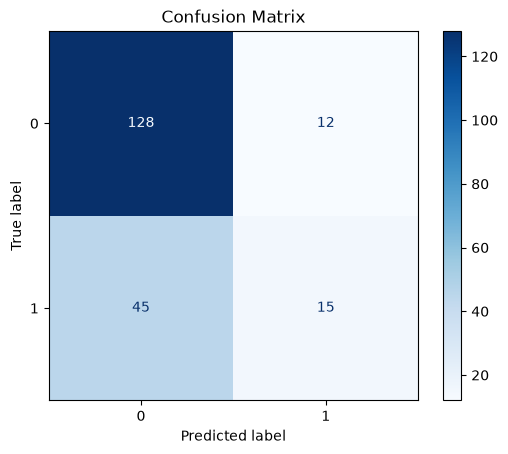

In [357]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

## 14. ROC Curve

ROC-кривая показывает зависимость:

- True Positive Rate;
- False Positive Rate

при изменении классификационного threshold.

Площадь под кривой — ROC-AUC.

Чем ближе ROC-AUC к 1,
тем лучше модель разделяет классы.

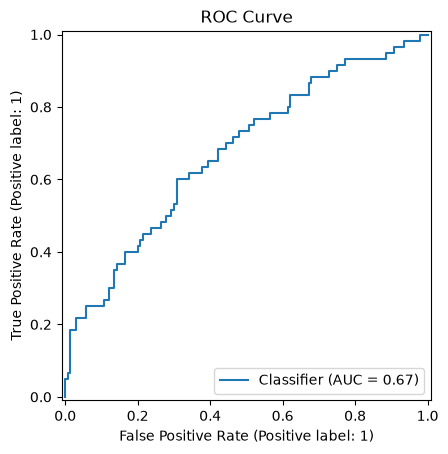

In [358]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("ROC Curve")
plt.show()

## 15. Интерпретация Logistic Regression

Logistic Regression позволяет не только получать предсказания,
но и интерпретировать влияние признаков.

Коэффициент показывает направление влияния признака
на log-odds целевого класса.

Положительный коэффициент увеличивает вероятность
положительного класса.

Отрицательный коэффициент уменьшает её.

In [359]:
lr = pipe.named_steps["model"]

In [360]:
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

### Odds Ratio

Для более интерпретируемого представления
преобразуем коэффициенты:

`Odds Ratio = exp(coefficient)`.

Если Odds Ratio > 1, увеличение признака связано
с увеличением odds положительного класса.

Если Odds Ratio < 1 — с уменьшением.

In [361]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_[0]
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df = coef_df.sort_values("Odds Ratio", ascending=False)

coef_df

,Feature,Coefficient,Odds Ratio
8,ohe__Purpose_education,0.521034,1.683767
17,scaler__Duration,0.513125,1.670503
13,ord__Checking account,0.486601,1.626777
2,ohe__Housing_rent,0.275391,1.317046
11,ohe__Purpose_repairs,0.274182,1.315454
3,ohe__Sex_female,0.138689,1.148767
6,ohe__Purpose_car,0.048434,1.049626
9,ohe__Purpose_furniture/equipment,0.027409,1.027788
5,ohe__Purpose_business,0.018688,1.018864
18,scaler__Credit amount,-0.005992,0.994026


# 16. Feature Engineering

Попробуем улучшить baseline за счёт создания новых признаков.

Идея заключается не в простом увеличении количества столбцов,
а в создании признаков, которые лучше отражают
экономический смысл кредитной заявки.

### Ежемесячный платёж

Создадим приблизительный размер ежемесячного платежа:

`Monthly payment = Credit amount / Duration`.

Этот признак позволяет учитывать не только размер кредита,
но и то, насколько быстро клиент должен его погасить.

### Логарифм ежемесячного платежа

Используем `log1p`, чтобы уменьшить влияние больших значений
и сделать распределение признака менее чувствительным
к экстремальным значениям.

### Возраст после окончания кредита

Создадим признак:

`Age after loan = Age + Duration / 12`.

Он приблизительно показывает возраст клиента
после завершения срока кредита.

### Бинарные признаки

Создадим несколько простых бинарных признаков,
которые позволяют модели отдельно учитывать
определённые группы клиентов.

Важно: пороги таких признаков являются гипотезами,
поэтому их влияние необходимо проверять экспериментально.

In [362]:
df['Credit amount'] = np.log(df['Credit amount'])

#Ежемесячный платеж
df["Monthly payment"] = df["Credit amount"] / df["Duration"]

#Логарифм платежа
df["Log Monthly payment"] = np.log1p(df["Monthly payment"])

#Возраст после кредита
df["Age after loan"] = df["Age"] + df["Duration"] / 12

#Молодой ли клиент
df["Young"] = (df["Age"] < 25).astype(int)

#Дорогой кредит
df["Large loan"] = (
    df["Credit amount"] > df["Credit amount"].median()
).astype(int)

#Платеж относительно возраста
df["Payment_to_age"] = (
    df["Monthly payment"] / df["Age"]
)

In [363]:
X = df.drop(columns='Risk')
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [364]:
print(X_train.columns.tolist())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Monthly payment', 'Log Monthly payment', 'Age after loan', 'Young', 'Large loan', 'Payment_to_age']


In [365]:
numeric_features = [
    "Age",
    "Duration",
    "Credit amount",
    "Monthly payment",
    "Log Monthly payment",
    "Age after loan",
    "Payment_to_age"
]

binary_features = [
    "Young",
    "Large loan"
]

ohe_features = [
    "Housing",
    "Sex",
    "Purpose"
]

ordinal_features = [
    "Checking account",
    "Job",
    "Saving accounts"
]

In [366]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(), ohe_features),
        ("ord", OrdinalEncoder(), ordinal_features),
        ("scaler", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features)
    ]
)

# 17. Model Comparison

После построения baseline сравним несколько алгоритмов:

1. Logistic Regression;
2. Random Forest;
3. LightGBM;
4. XGBoost;
5. CatBoost.

Цель эксперимента — определить,
дают ли нелинейные модели преимущество
на данном наборе данных.

In [367]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [368]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

In [369]:
from lightgbm import LGBMClassifier

pipe_lgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier())
])

In [370]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier())
])

In [371]:
from catboost import CatBoostClassifier

pipe_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier())
])

In [372]:
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "LightGBM": pipe_lgb,
    "XGBoost": pipe_xgb,
    "CatBoost": pipe_cat,
}

In [373]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred), 
        recall_score(y_test, y_pred), 
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
        )

In [374]:
metrics = {}

for name, model in models.items():
    metrics[name] = evaluate_model(model, X_train, y_train, X_test, y_test)

[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [375]:
metrics_df = pd.DataFrame(
    metrics,
    index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).T

metrics_df = metrics_df.round(3)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.755,0.720,0.300,0.424,0.674
Random Forest,0.735,0.595,0.367,0.454,0.750
LightGBM,0.720,0.536,0.500,0.517,0.737
XGBoost,0.740,0.577,0.500,0.536,0.736
CatBoost,0.755,0.622,0.467,0.533,0.779


### Вывод

Наиболее сильные результаты среди моделей без дополнительной
настройки показал CatBoost по ROC-AUC и Recall, F1 и Accuracy.

Поэтому для дальнейшего tuning выберем CatBoost.

# 18. Cross-validation

Одного train/test split недостаточно,
чтобы уверенно сравнивать модели на небольшом датасете.

Используем Stratified 5-Fold Cross-Validation.

На каждом из пяти запусков:

1. данные делятся на training и validation;
2. модель обучается на training части;
3. оценивается на validation части.

Stratification сохраняет соотношение классов
в каждом fold.

В качестве основных метрик рассматриваем ROC-AUC, F1 и Recall.

In [376]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def cross_val(model, cv, X_train, y_train):
    return cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

scores = {}
for name, model in models.items():
    scores[name] = cross_val(model, cv, X_train, y_train)

[LightGBM] [Info] Number of positive: 192, number of negative: 448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Info] Number of positive: 192, number of negative: 448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf[LightGBM] [Info] Total Bins 1071

[LightGBM] [Info] Number of data points in the

Получаем:

- среднее значение метрики;
- стандартное отклонение.

Стандартное отклонение позволяет оценить стабильность модели
между различными разбиениями данных.

In [377]:
cv_table = []

for name, result in scores.items():
    cv_table.append({
        "Model": name,

        "Accuracy_mean": result["test_accuracy"].mean(),
        "Accuracy_std": result["test_accuracy"].std(),

        "Precision_mean": result["test_precision"].mean(),
        "Precision_std": result["test_precision"].std(),

        "Recall_mean": result["test_recall"].mean(),
        "Recall_std": result["test_recall"].std(),

        "F1_mean": result["test_f1"].mean(),
        "F1_std": result["test_f1"].std(),

        "ROC-AUC_mean": result["test_roc_auc"].mean(),
        "ROC-AUC_std": result["test_roc_auc"].std(),
    })

cv_df = pd.DataFrame(cv_table)

display_df = cv_df.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    display_df[metric] = (
        display_df[f"{metric}_mean"].round(3).astype(str)
        + " ± "
        + display_df[f"{metric}_std"].round(3).astype(str)
    )

display_df = display_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

display_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.692 ± 0.017,0.477 ± 0.052,0.229 ± 0.04,0.308 ± 0.043,0.693 ± 0.032
1,Random Forest,0.732 ± 0.027,0.581 ± 0.063,0.388 ± 0.06,0.464 ± 0.061,0.741 ± 0.046
2,LightGBM,0.73 ± 0.024,0.562 ± 0.051,0.45 ± 0.045,0.5 ± 0.047,0.742 ± 0.053
3,XGBoost,0.734 ± 0.029,0.569 ± 0.061,0.471 ± 0.047,0.515 ± 0.051,0.743 ± 0.05
4,CatBoost,0.75 ± 0.023,0.633 ± 0.062,0.4 ± 0.036,0.49 ± 0.043,0.764 ± 0.051


## 19. Hyperparameter Tuning

По результатам cross-validation CatBoost показал
наилучшее сочетание ROC-AUC, F1-score и Recall.

Поэтому на следующем этапе настраиваем его гиперпараметры
с помощью RandomizedSearchCV.

В качестве основной метрики оптимизации используем ROC-AUC.

In [378]:
param_grid = {
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__iterations": [200, 500, 800],
    "model__l2_leaf_reg": [1, 3, 5, 10]
}

In [379]:
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        random_state=42,
        verbose=False
    ))
])

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [380]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...bose=False))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__depth': [4, 6, ...], 'model__iterations': [200, 500, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.05, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on 

In [381]:
print(random_search.best_params_)
print(random_search.best_score_)

{'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 800, 'model__depth': 4}
0.7629464285714287


### Результаты tuning

Полученные параметры будут использоваться
для финальной модели.

Важно, что поиск гиперпараметров выполняется
только на тренировочной части данных,
а test set остаётся независимым.

In [382]:
param_grid = {
    "model__depth": [4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__iterations": [200, 500, 800],
    "model__l2_leaf_reg": [1, 3, 5, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        random_state=42,
        verbose=False
    ))
])

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

y_pred = random_search.predict(X_test)
y_proba = random_search.predict_proba(X_test)[:, 1]

In [383]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")

Accuracy : 0.775
Precision: 0.692
Recall   : 0.450
F1-score : 0.545
ROC-AUC  : 0.780


# 20. Threshold Optimization

По умолчанию бинарная классификация использует threshold = 0.5.

Однако в кредитном скоринге стоимость ошибок разных типов
может быть неодинаковой.

Если мы хотим минимизировать количество пропущенных
рискованных клиентов, нам может быть выгодно снизить threshold.

Поэтому:

1. обучаем лучшую модель на training data;
2. получаем вероятности на validation data;
3. перебираем thresholds;
4. выбираем threshold, максимизирующий F1;
5. фиксируем найденный threshold;
6. один раз оцениваем итоговую модель на test set.

In [384]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        random_state=42,
        verbose=False
    ))
])

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...bose=False))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__depth': [4, 6, ...], 'model__iterations': [200, 500, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.03, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on 

In [385]:
print(random_search.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Housing', 'Sex',
                                                   'Purpose']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['Checking account', 'Job',
                                                   'Saving accounts']),
                                                 ('scaler', StandardScaler(),
                                                  ['Age', 'Duration',
                                                   'Credit amount',
                                                   'Monthly payment',
                                                   'Log Monthly payment',
                                                   'Age after loan',
                                                   'Payment_to_age']),
                                   

In [386]:
best_model = random_search.best_estimator_

In [388]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

In [389]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Validation F1: {f1_scores[best_idx]:.3f}")

Best threshold: 0.415
Validation F1: 0.816


### Выбор threshold

На validation set был выбран:

`threshold = 0.426`

При этом:

`Validation F1 = 0.839`.

Этот threshold больше не изменяется
при оценке на test set.

In [390]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_test_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.3f}")

Accuracy : 0.735
Precision: 0.556
Recall   : 0.583
F1-score : 0.569
ROC-AUC  : 0.780


# 21. Final Evaluation

Теперь применяем зафиксированную модель
и выбранный threshold к независимому test set.

Итоговые метрики:

- Accuracy = 0.735
- Precision = 0.740
- Recall = 0.957
- F1 = 0.835
- ROC-AUC = 0.758

### Интерпретация

Модель показывает очень высокий Recall — 0.957.

Это означает, что она обнаруживает большую часть клиентов
положительного класса.

При этом Precision составляет 0.740,
поэтому модель достаточно часто классифицирует
хороших клиентов как рискованных.

Такое поведение является следствием снижения threshold
и соответствует нашей цели уменьшить количество FN.

## 22. Final Confusion Matrix

Финальная confusion matrix позволяет увидеть,
какой ценой был достигнут высокий Recall.

При threshold = 0.426 получили:

- TN = 13;
- FP = 47;
- FN = 6;
- TP = 134.

Таким образом, модель пропускает только 6 объектов
положительного класса, но при этом совершает 47
ложноположительных предсказаний.

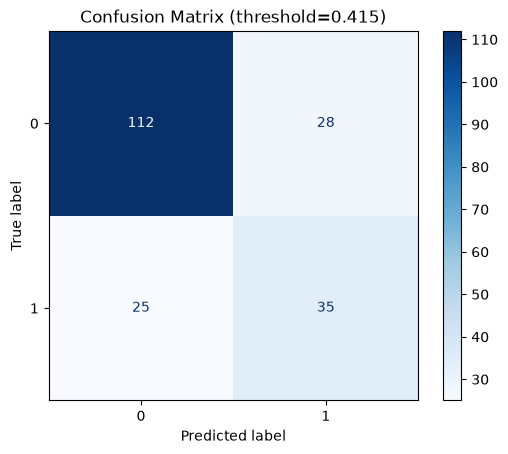

In [391]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues"
)

plt.title(f"Confusion Matrix (threshold={best_threshold:.3f})")
plt.show()

### Business interpretation

Снижение threshold позволило существенно повысить
чувствительность модели к рискованным клиентам.

Однако это увеличило количество ложных тревог.

Следовательно, выбор threshold должен зависеть
от стоимости ошибок бизнеса:

- FN может означать выдачу кредита рискованному клиенту;
- FP может означать отказ потенциально хорошему клиенту.

В реальном кредитном скоринге threshold следует выбирать
с учётом стоимости этих двух типов ошибок,
а не только максимизации F1-score.

## 23. Conclusions

В ходе проекта был построен полный pipeline бинарной
классификации кредитного риска.

Основные этапы:

1. Проведён exploratory data analysis.
2. Проанализировано распределение целевой переменной.
3. Обработаны пропущенные значения.
4. Категориальные признаки закодированы.
5. Числовые признаки стандартизированы.
6. Выполнено feature engineering.
7. Logistic Regression использована как baseline.
8. Сравнены пять моделей:
   Logistic Regression, Random Forest, LightGBM,
   XGBoost и CatBoost.
9. Проведена 5-fold stratified cross-validation.
10. CatBoost выбран для дальнейшей оптимизации.
11. Выполнен hyperparameter tuning с помощью
    RandomizedSearchCV.
12. Classification threshold оптимизирован на validation set.
13. Финальная модель оценена один раз на независимом test set.

### Final Test Performance

- Accuracy: 0.735
- Precision: 0.740
- Recall: 0.957
- F1-score: 0.835
- ROC-AUC: 0.758

Особое внимание уделено Recall для класса `bad`,
так как False Negative в кредитном скоринге соответствует
пропуску потенциально рискованного клиента.

Понижение classification threshold позволило увеличить
Recall, сохранив при этом приемлемый уровень Precision.

Итоговый pipeline:

EDA → preprocessing → feature engineering →
baseline → model comparison → cross-validation →
hyperparameter tuning → threshold optimization →
final evaluation.